# 06 · Sequence Autoencoders (LSTM) — Anomaly Detection in Time-Series & Sensors

Notebook 03 detected anomalies in **tabular** rows. But a huge class of consulting problems is
**temporal**: turbine vibration, ECG heartbeats, server metrics, IoT sensor streams, transactions
over time. Here **the order and dynamics are the signal** — a fault is a *pattern* unfolding in time,
not a single out-of-range value. A tabular autoencoder throws that order away.

The fix combines two ideas you already know: the **autoencoder** (nb 01–04) and the **LSTM** (from
your RNN course). An **LSTM autoencoder** encodes an entire *sequence window* into one fixed code and
reconstructs the whole sequence. Train it on normal operation, and **abnormal sequences reconstruct
badly** — the same reconstruction-error trick, now for time.

**What you will learn here**

1. The **sequence-to-sequence autoencoder** architecture (the "EncDec-AD" pattern): LSTM encoder →
   code → LSTM decoder.
2. Train on **normal windows only**, score each window by **reconstruction error**.
3. The killer feature: **localize *when* the anomaly happens** inside a window via per-timestep error.
4. Catch a **pattern anomaly** (a frequency change) whose individual values are all *in normal range* —
   invisible to value-threshold rules, the temporal analogue of nb 03's correlation-breaking demo.
5. Benchmark vs a **non-temporal baseline** (PCA on the flattened window) and know when sequences matter.

> Framework: **PyTorch**, CPU-only. Data: **synthetic multivariate sensor windows** (offline).


## 1. Why sequences need their own autoencoder

Take a window of a 3-sensor signal, length 32. You *could* flatten it to 96 numbers and use a tabular
AE. Two problems:

- **Order is lost / brittle.** Flattening ties each value to a fixed *position*. But real signals drift
  in **phase** (the same healthy cycle can start anywhere in the window), so "position 5" means nothing
  stable. A recurrent model reads the signal **as a process**, sharing the same dynamics across time.
- **Fixed length.** Flattening demands a fixed window; sequences in the wild vary in length. An LSTM
  handles arbitrary lengths natively.

The sequence autoencoder (a **seq2seq** model used as an autoencoder):

```
  INPUT SEQUENCE                    CODE                 RECONSTRUCTED SEQUENCE
  x1 x2 x3 ... xT                (one vector)             x̂1 x̂2 x̂3 ... x̂T

  x1─▶x2─▶x3─▶ ... ─▶xT
   │   │   │          │            ┌────┐        repeat code T times, decode
   ▼   ▼   ▼          ▼            │ z  │        ┌──▶ x̂1 x̂2 x̂3 ... x̂T
  ┌──────────────────────┐  h_T   │(h_T)│ ──────▶│    (LSTM decoder + linear head)
  │   LSTM  ENCODER       │ ─────▶ └────┘        └──────────────────────────────┘
  └──────────────────────┘        the summary
                                  of the whole window

  Loss = || x - x̂ ||²  over the WHOLE sequence.   Train on NORMAL windows only.
```

The encoder's **final hidden state** `h_T` is a fixed-size summary of the entire window — the code.
The decoder unrolls it back into a sequence. Anomalous dynamics don't fit the learned summary → high
reconstruction error.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__, "| device: CPU")


torch 2.12.1+cu130 | device: CPU


## 2. Synthetic multivariate sensor data

Think of a healthy rotating machine with **3 sensors**. Normal operation is a smooth, quasi-periodic
signal: each window is a sine at a frequency in a **narrow healthy band**, with a **random phase**
(the window can start anywhere in the cycle), slight amplitude variation, and sensor noise. The 3
channels are phase-shifted versions of the same underlying motion (correlated).

We then craft three realistic **fault** types:

| Fault | What it looks like | Detectable by a value threshold? |
|---|---|---|
| **Spike** | a sharp transient (impact / electrical glitch) | yes — value goes out of range |
| **Level shift** | a step offset midway (sensor drift / bias) | maybe |
| **Frequency shift** | the machine runs at the *wrong speed* — same amplitude, different rhythm | **no** — every value is in normal range |

The **frequency shift** is the interesting one: a naïve min/max rule sees nothing wrong.


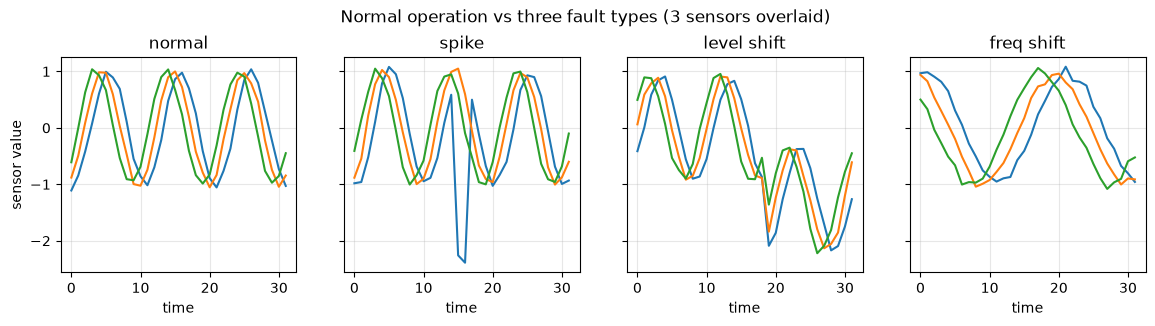

In [2]:
L, C = 32, 3           # window length, number of channels/sensors
t = np.linspace(0, 1, L)

def normal_window():
    f  = np.random.uniform(2.8, 3.2)      # healthy frequency band
    ph = np.random.uniform(0, 2*np.pi)    # random phase (window starts anywhere)
    a  = np.random.uniform(0.9, 1.1)
    w = np.stack([a*np.sin(2*np.pi*f*t + ph + c*0.6) for c in range(C)], axis=1)
    return (w + 0.05*np.random.randn(L, C)).astype("float32")

def anomaly_window(kind):
    w = normal_window()
    if kind == "spike":
        p = np.random.randint(4, L-4); ch = np.random.randint(C)
        w[p:p+2, ch] += np.random.choice([-1, 1]) * np.random.uniform(2.5, 3.5)
    elif kind == "levelshift":
        p = np.random.randint(L//3, 2*L//3)
        w[p:, :] += np.random.choice([-1, 1]) * np.random.uniform(1.2, 1.8)
    elif kind == "freq":                  # PATTERN anomaly: wrong speed, same amplitude range
        f = np.random.choice([np.random.uniform(1.2, 1.8), np.random.uniform(4.5, 5.5)])
        ph = np.random.uniform(0, 2*np.pi); a = np.random.uniform(0.9, 1.1)
        w = np.stack([a*np.sin(2*np.pi*f*t + ph + c*0.6) for c in range(C)], axis=1)
        w = (w + 0.05*np.random.randn(L, C)).astype("float32")
    return w

# Visualise one normal and one of each anomaly
fig, axes = plt.subplots(1, 4, figsize=(14, 2.8), sharey=True)
for ax, (title, w) in zip(axes, [("normal", normal_window()),
                                  ("spike", anomaly_window("spike")),
                                  ("level shift", anomaly_window("levelshift")),
                                  ("freq shift", anomaly_window("freq"))]):
    ax.plot(w); ax.set_title(title); ax.set_xlabel("time"); ax.grid(alpha=0.3)
axes[0].set_ylabel("sensor value")
fig.suptitle("Normal operation vs three fault types (3 sensors overlaid)", y=1.05); plt.show()


In [3]:
# Build datasets. TRAIN = normal only. TEST = held-out normal + a mix of anomalies.
N_TRAIN, N_TEST_NORMAL, N_TEST_ANOM = 4000, 1000, 600
X_train = np.stack([normal_window() for _ in range(N_TRAIN)])

kinds = (["spike"]*(N_TEST_ANOM//3) + ["levelshift"]*(N_TEST_ANOM//3) + ["freq"]*(N_TEST_ANOM - 2*(N_TEST_ANOM//3)))
X_test = np.stack([normal_window() for _ in range(N_TEST_NORMAL)] + [anomaly_window(k) for k in kinds])
y_test = np.array([0]*N_TEST_NORMAL + [1]*N_TEST_ANOM)
test_kind = np.array(["normal"]*N_TEST_NORMAL + kinds)

Xtr = torch.tensor(X_train)
Xte = torch.tensor(X_test)
print("train (normal):", tuple(Xtr.shape), "| test:", tuple(Xte.shape), "| anomalies:", int(y_test.sum()))


train (normal): (4000, 32, 3) | test: (1600, 32, 3) | anomalies: 600


## 3. Build the LSTM autoencoder

- **Encoder** — an `nn.LSTM` reads the window; we keep the **final hidden state** as the code `z`.
- **Bridge** — repeat `z` at every timestep to feed the decoder (the simplest, most common decoder
  input for a seq2seq AE).
- **Decoder** — another `nn.LSTM` unrolls `z` back over time, and a `Linear` head maps each step's
  hidden state to the 3 sensor values.


In [4]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_channels=3, hidden=32):
        super().__init__()
        self.encoder = nn.LSTM(n_channels, hidden, batch_first=True)
        self.decoder = nn.LSTM(hidden, hidden, batch_first=True)
        self.head    = nn.Linear(hidden, n_channels)
        self.hidden  = hidden

    def forward(self, x):
        B, L, _ = x.shape
        _, (h_n, _) = self.encoder(x)          # h_n: (1, B, hidden) — summary of the window
        code = h_n[-1]                         # (B, hidden)  = z
        repeated = code.unsqueeze(1).repeat(1, L, 1)   # feed the code at every decoder step
        dec_out, _ = self.decoder(repeated)    # (B, L, hidden)
        return self.head(dec_out)              # (B, L, n_channels) reconstruction

model = LSTMAutoencoder()
print(model)
print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}")


LSTMAutoencoder(
  (encoder): LSTM(3, 32, batch_first=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=3, bias=True)
)
parameters: 13,283


epoch  5 | train MSE 0.0261


epoch 10 | train MSE 0.0076


epoch 15 | train MSE 0.0075


epoch 20 | train MSE 0.0053


epoch 25 | train MSE 0.0050


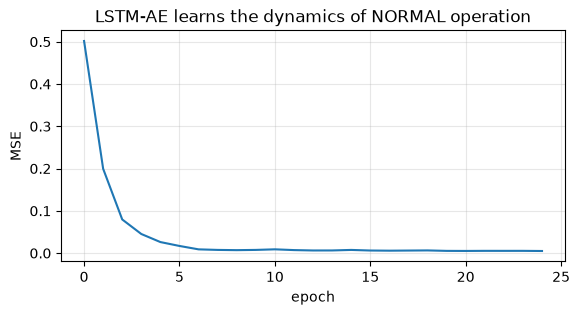

In [5]:
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
loss_fn = nn.MSELoss()
EPOCHS, BATCH = 25, 128
n = len(Xtr); hist = []
for epoch in range(EPOCHS):
    model.train(); perm = torch.randperm(n); run = 0.0
    for i in range(0, n, BATCH):
        xb = Xtr[perm[i:i+BATCH]]
        loss = loss_fn(model(xb), xb)          # reconstruct NORMAL windows
        opt.zero_grad(); loss.backward(); opt.step()
        run += loss.item()*len(xb)
    hist.append(run/n)
    if (epoch+1) % 5 == 0:
        print(f"epoch {epoch+1:2d} | train MSE {run/n:.4f}")

plt.figure(figsize=(6.5, 3)); plt.plot(hist); plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("LSTM-AE learns the dynamics of NORMAL operation"); plt.grid(alpha=0.3); plt.show()


## 4. Reconstructions: normal fits, faults don't

The model reconstructs a **normal** window almost perfectly (it learned the healthy dynamics) but
**cannot** reproduce a fault it never saw — the mismatch is the anomaly signal.


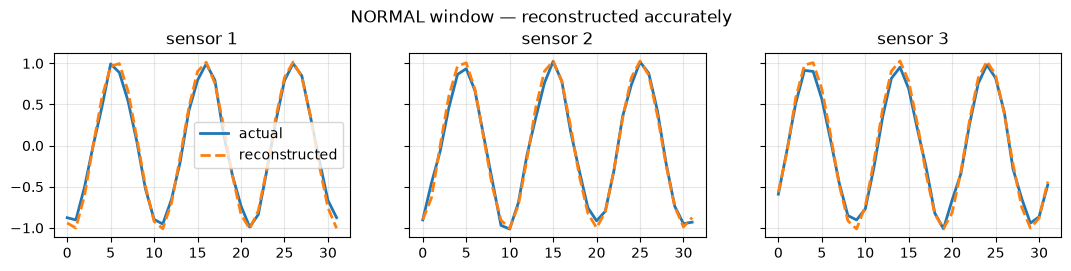

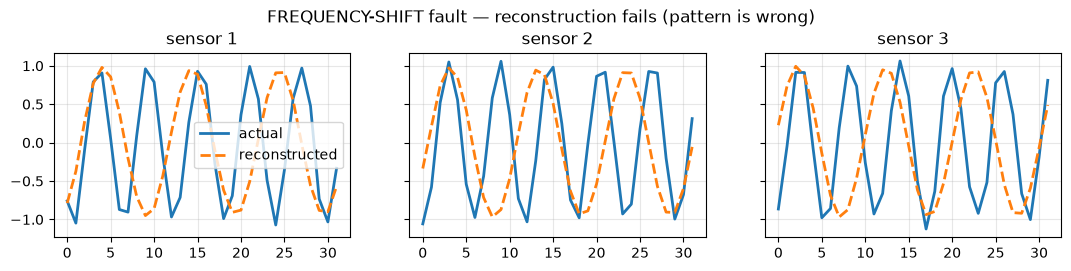

In [6]:
model.eval()
def show_recon(w, title):
    x = torch.tensor(w[None])
    with torch.no_grad():
        xh = model(x)[0].numpy()
    fig, axes = plt.subplots(1, C, figsize=(13, 2.4), sharey=True)
    for c in range(C):
        axes[c].plot(w[:, c], label="actual", lw=2)
        axes[c].plot(xh[:, c], "--", label="reconstructed", lw=2)
        axes[c].set_title(f"sensor {c+1}"); axes[c].grid(alpha=0.3)
    axes[0].legend(); fig.suptitle(title, y=1.06); plt.show()

np.random.seed(3)
show_recon(normal_window(),          "NORMAL window — reconstructed accurately")
show_recon(anomaly_window("freq"),   "FREQUENCY-SHIFT fault — reconstruction fails (pattern is wrong)")


## 5. Reconstruction error = anomaly score

Per window, the anomaly score is the mean squared reconstruction error over all timesteps and
channels. As before, the whole method rests on the score **separating** normal from anomalous.


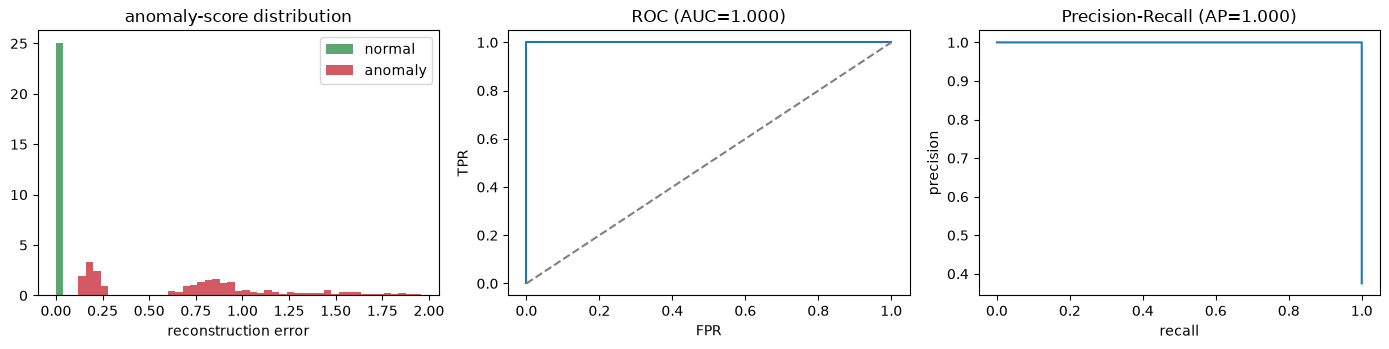

ROC-AUC 1.000 | PR-AUC 1.000

threshold tau = 0.0099  (99th pct of normal training error)
  spike      : detected 100.0% of 200 windows
  levelshift : detected 100.0% of 200 windows
  freq       : detected 100.0% of 200 windows
  false alarms on normal: 1.1%


In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

with torch.no_grad():
    recon_te = model(Xte).numpy()
errors = ((recon_te - X_test) ** 2).mean(axis=(1, 2))    # (n_test,) one score per window

roc = roc_auc_score(y_test, errors)
pr  = average_precision_score(y_test, errors)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
bins = np.linspace(0, np.percentile(errors, 99), 50)
ax[0].hist(errors[y_test==0], bins=bins, alpha=0.7, label="normal", color="#1a7f37", density=True)
ax[0].hist(errors[y_test==1], bins=bins, alpha=0.7, label="anomaly", color="#c1121f", density=True)
ax[0].set_title("anomaly-score distribution"); ax[0].set_xlabel("reconstruction error"); ax[0].legend()
fpr, tpr, _ = roc_curve(y_test, errors); ax[1].plot(fpr, tpr); ax[1].plot([0,1],[0,1],"--",color="gray")
ax[1].set_title(f"ROC (AUC={roc:.3f})"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
prec, rec, _ = precision_recall_curve(y_test, errors); ax[2].plot(rec, prec)
ax[2].set_title(f"Precision-Recall (AP={pr:.3f})"); ax[2].set_xlabel("recall"); ax[2].set_ylabel("precision")
plt.tight_layout(); plt.show()
print(f"ROC-AUC {roc:.3f} | PR-AUC {pr:.3f}")

# detection rate per fault type at a 99th-percentile-of-normal threshold
with torch.no_grad():
    train_err = ((model(Xtr).numpy() - X_train)**2).mean(axis=(1,2))
tau = np.percentile(train_err, 99)
print(f"\nthreshold tau = {tau:.4f}  (99th pct of normal training error)")
for k in ["spike", "levelshift", "freq"]:
    m = test_kind == k
    print(f"  {k:11s}: detected {100*(errors[m] > tau).mean():5.1f}% of {m.sum()} windows")
print(f"  false alarms on normal: {100*(errors[y_test==0] > tau).mean():.1f}%")


## 6. **Localize the fault in time** — the operational payoff

A single score says *"this window is abnormal"*. Maintenance teams also need *"**when** did it go
wrong?"* Because the AE reconstructs every timestep, the **per-timestep error** pinpoints the moment
the signal departed from normal — turning a flag into an actionable, explainable alert.


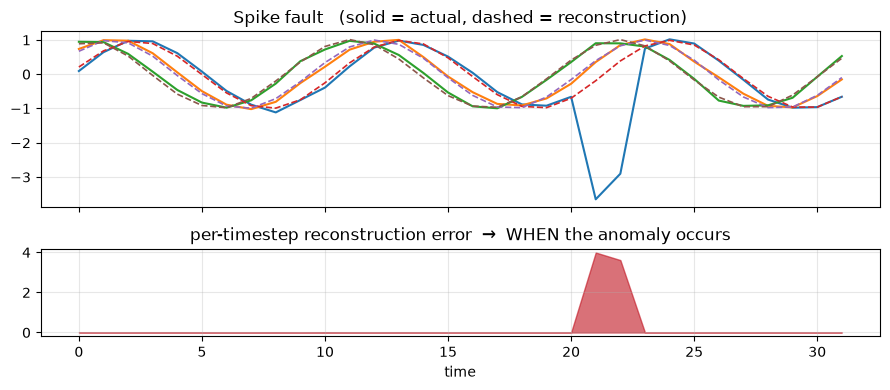

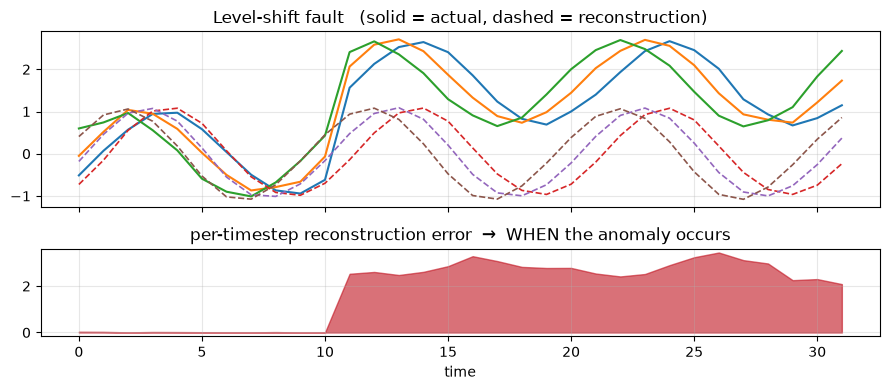

In [8]:
def localize(w, title):
    x = torch.tensor(w[None])
    with torch.no_grad():
        xh = model(x)[0].numpy()
    per_t = ((xh - w) ** 2).mean(axis=1)          # error at each timestep (mean over channels)
    fig, ax = plt.subplots(2, 1, figsize=(9, 4), sharex=True, gridspec_kw={"height_ratios":[2,1]})
    ax[0].plot(w, lw=1.5); ax[0].plot(xh, "--", lw=1.2)
    ax[0].set_title(title + "   (solid = actual, dashed = reconstruction)"); ax[0].grid(alpha=0.3)
    ax[1].fill_between(range(len(per_t)), per_t, color="#c1121f", alpha=0.6)
    ax[1].set_title("per-timestep reconstruction error  →  WHEN the anomaly occurs")
    ax[1].set_xlabel("time"); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

np.random.seed(11)
localize(anomaly_window("spike"),      "Spike fault")
localize(anomaly_window("levelshift"), "Level-shift fault")


## 7. Does the temporal model actually help? Baseline vs LSTM-AE

We compare against a **non-temporal** detector: flatten each window to `L·C = 96` numbers and use
**PCA reconstruction error** (the same linear baseline from nb 03, now on flattened windows). We
report overall AUC plus per-fault detection — including the **frequency-shift** fault, whose values
are all in normal range (invisible to a *value threshold*), to see whether the simple linear baseline
still copes.


detector          ROC-AUC   PR-AUC  freq-detect
LSTM-AE             1.000    1.000       100.0%
PCA (flattened)     1.000    1.000       100.0%


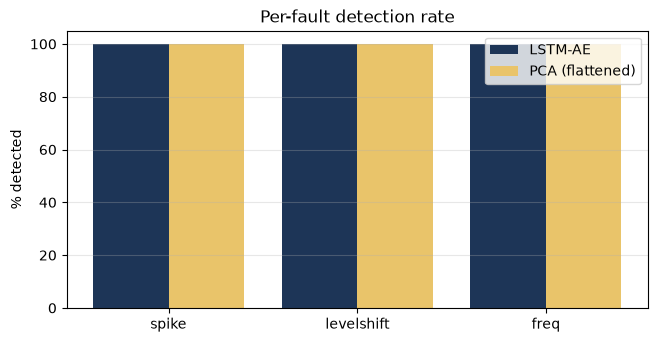

In [9]:
from sklearn.decomposition import PCA

Xtr_flat = X_train.reshape(len(X_train), -1)
Xte_flat = X_test.reshape(len(X_test), -1)
pca = PCA(n_components=16).fit(Xtr_flat)
rec_pca = pca.inverse_transform(pca.transform(Xte_flat))
err_pca = ((Xte_flat - rec_pca) ** 2).mean(axis=1)
tau_pca = np.percentile(((Xtr_flat - pca.inverse_transform(pca.transform(Xtr_flat)))**2).mean(1), 99)

print(f"{'detector':16s} {'ROC-AUC':>8} {'PR-AUC':>8} {'freq-detect':>12}")
for name, e, tau_ in [("LSTM-AE", errors, tau), ("PCA (flattened)", err_pca, tau_pca)]:
    r = roc_auc_score(y_test, e); p = average_precision_score(y_test, e)
    fd = 100*(e[test_kind=="freq"] > tau_).mean()
    print(f"{name:16s} {r:8.3f} {p:8.3f} {fd:11.1f}%")

# bar chart of per-fault detection: LSTM-AE vs PCA
faults = ["spike", "levelshift", "freq"]
lstm_det = [100*(errors[test_kind==k] > tau).mean() for k in faults]
pca_det  = [100*(err_pca[test_kind==k] > tau_pca).mean() for k in faults]
x = np.arange(len(faults))
plt.figure(figsize=(7.5, 3.6))
plt.bar(x-0.2, lstm_det, width=0.4, label="LSTM-AE", color="#1d3557")
plt.bar(x+0.2, pca_det,  width=0.4, label="PCA (flattened)", color="#e9c46a")
plt.xticks(x, faults); plt.ylabel("% detected"); plt.ylim(0, 105)
plt.title("Per-fault detection rate"); plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.show()


**Reading the benchmark — and an honest lesson.** On this clean, **fixed-length** synthetic data,
*both* detectors do very well, including on the frequency shift. That is the point worth internalising
for an interview: **for fixed-length windows with simple dynamics, a linear baseline like PCA is
strong and often sufficient** — do not reach for an LSTM by reflex (it's slower, needs more data, and
is harder to tune). This mirrors nb 03: match model complexity to the structure.

So when *does* the LSTM autoencoder genuinely earn its place? When the linear/flattened view breaks
down: **(1) variable-length** sequences (flattening needs a fixed size); **(2) complex, nonlinear
dynamics** a linear PCA subspace can't span (regime changes, interactions across many sensors);
**(3) streaming / online** scoring; and **(4)** when you want the natural **per-timestep
localization** shown above. On simple sinusoids none of those bite — so PCA keeps up. Engineer the
comparison onto harder, nonlinear dynamics (see "Try it yourself") and the gap opens.


## 8. Practical notes for time-series anomaly detection

- **Windowing.** Choose the window length to span at least one full cycle / the timescale of faults
  you care about. Slide the window (with overlap) to score a **stream** continuously.
- **Two families of detectors.** *Reconstruction-based* (this notebook — encode & rebuild a window)
  vs *forecasting-based* (predict the next step from the past; error = surprise, à la your RNN
  forecasting notebooks). Both use "prediction error as anomaly score"; reconstruction sees the whole
  window at once, forecasting is naturally causal/online.
- **Thresholding & smoothing.** Set `τ` from normal-data error percentiles; smooth per-timestep scores
  (moving average) and require a few consecutive exceedances to cut false alarms.
- **Reference.** This encoder–decoder reconstruction approach is **EncDec-AD** (Malhotra et al., 2016),
  a standard industrial baseline for multi-sensor machine health.
- **VAE variant.** Swap the LSTM-AE for an **LSTM-VAE** to get a *probabilistic* score (likelihood) and
  uncertainty — useful when you need calibrated alerts.


## 9. Key takeaways & interview soundbites

**The mental model**

- An **LSTM autoencoder** encodes a whole sequence window into one code (the encoder's final hidden
  state) and reconstructs the sequence. Train on **normal** windows; **reconstruction error = anomaly
  score** — the nb 03 recipe, upgraded to respect **time**.
- It catches **temporal/pattern anomalies** (wrong rhythm, wrong dynamics) that a **value threshold**
  misses, and its **per-timestep error localizes when** the fault occurred. But be honest: on simple,
  fixed-length windows a linear baseline (PCA on the flattened window) is strong too — the LSTM's edge
  shows up on **variable-length, nonlinear, or streaming** signals.

**Sharp answers for an interview**

- *"Why not just flatten the window and use a normal autoencoder?"* → Flattening ties meaning to fixed
  positions, so it's brittle to phase shifts and can't handle variable-length sequences. An LSTM reads
  the signal as a process and shares dynamics across time — better for real, phase-varying sensors.
- *"How do you detect and localize a fault?"* → Score each window by total reconstruction error for
  *detection*; use the per-timestep error curve for *localization* — a big operational win for
  maintenance teams.
- *"Reconstruction vs forecasting for time-series anomalies?"* → Reconstruction (seq2seq AE) sees the
  full window and is great for offline/windowed detection; forecasting (predict next step) is causal
  and natural for streaming. Both threshold a prediction error.
- *"When is this overkill?"* → If faults are simple out-of-range spikes, a rule or a tabular detector
  is cheaper. Bring the LSTM-AE when the anomaly is in the **dynamics** and values look individually
  normal.

**Try it yourself**

1. Make normal dynamics **nonlinear** (e.g. a Van-der-Pol / Duffing oscillator, or amplitude-modulated
   signal) and re-run the benchmark — this is where the LSTM-AE should pull ahead of linear PCA.
2. Reconstruct the sequence **in reverse** (a classic seq2seq-AE trick) and compare.
3. Turn it into an **LSTM-VAE** (add μ/logσ² heads + KL, as in nb 05) for a probabilistic score.
4. Shrink the code (`hidden`) — too small underfits normal; too large reconstructs anomalies too.
